In [1]:
import pandas as pd
from plotnine import *
import os

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

In [4]:
import pandas as pd
df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_results.csv')
df[(df['rho']==1)&(df['run_name']=='SCoNE')].head(20)

,Unnamed: 0,run_name,factor_matrix,init,sim,rel_error_G,rel_error_C,rho,lambda_val,split,rank
856,0,SCoNE,W_C,0,0.882258,0.666165,0.719940,1.0,0.0,tune,3
857,1,SCoNE,W_G,0,0.882258,0.666165,0.719940,1.0,0.0,tune,3
858,2,SCoNE,H_G,0,0.865123,0.666165,0.719940,1.0,0.0,tune,3
859,3,SCoNE,U_G,0,0.709019,0.666165,0.719940,1.0,0.0,tune,3
860,4,SCoNE,H_C,0,0.904042,0.666165,0.719940,1.0,0.0,tune,3
861,5,SCoNE,U_C,0,0.798306,0.666165,0.719940,1.0,0.0,tune,3
862,6,SCoNE,W_C,1,0.924116,0.662263,0.712239,1.0,0.0,tune,3
863,7,SCoNE,W_G,1,0.924116,0.662263,0.712239,1.0,0.0,tune,3
864,8,SCoNE,H_G,1,0.958633,0.662263,0.712239,1.0,0.0,tune,3
865,9,SCoNE,U_G,1,0.707290,0.662263,0.712239,1.0,0.0,tune,3


In [2]:
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output'
os.makedirs(f'{output_dir}/figures',exist_ok=True)

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [3]:
def graph_plots(summary,variable_name,x_axis_name,y_axis_name,output_path,facet_by_factor_matrix=True,comparator_method_plot=True):
    # variable name is true var name, x-axis name is specific name for x-axis label (like if need latex)
    # if facet_by_factor_matrix is True, facet_wrap by factor matrix else don't
    # baseline methods
    p = (
        ggplot(summary[summary['run_name'].isin(['G-NMF','C-NMF','G-CoNE','C-CoNE','CoNE','SCoNE','SCoNE(Fro)','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + labs(y=y_axis_name,x=x_axis_name,color="")
        + theme_bw()
    )
    if facet_by_factor_matrix:
        p = p + facet_wrap('factor_matrix', nrow=1) + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
    else:
        p = p + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top') + ylim(0.5,0.9)
    p.save(f'{output_path}_baseline.jpeg',dpi=300)

    # comparator methods
    if comparator_method_plot:
        p = (
            ggplot(summary[summary['run_name'].isin(['SCoNE','RGWAS','MVBC','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
            + geom_point(size=2)
            + geom_line()
            + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
            + scale_color_manual(values=colors_dict)
            + labs(y=y_axis_name,x=x_axis_name,color="")
            + theme_bw()
            + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
        )
        if facet_by_factor_matrix:
            p = p + facet_wrap('factor_matrix', nrow=1) + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
        else:
            p = p + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top')
        p.save(f'{output_path}_comparator.jpeg',dpi=300)

In [ ]:
# visualize a loss
with open('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/models/loss_function_lambdaval_0_noise_0.5_init_0.json')

In [7]:
from test_reconstruction import get_summary_df
df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_results.csv')
# get best params based on tuning

# get summary for best params for split train
summary_sim = get_summary_df(df,["run_name", "factor_matrix", "rho","rank"],"sim")
# subset to W_C since rel_error recordings for all factor matrices are duplicates (don't differ by factor matrix)
summary_relerror_G = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "rho","rank"],"rel_error_G") 
summary_relerror_C = get_summary_df(df[df['factor_matrix']=='W_C'],["run_name", "lambda_val", "rho","rank"],"rel_error_C")

assert summary_sim[(summary_sim['run_name']=='MVBC')&(summary_sim['std']!=0)].shape[0] == 0
graph_plots(summary_sim[summary_sim['factor_matrix'].str.startswith('W')],"rho",y_axis_name="Similarity",
            x_axis_name=r"$\rho$",output_path=f'{output_dir}/figures/rho')

AssertionError: 

In [78]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary_rel_error_C.csv',index_col=0)
graph_plots(summary[(summary['run_name']!='SCoNE(Fro)')&(~summary['mean'].isna())],"rho",y_axis_name="Relative Error (C)",x_axis_name=r"$\rho$",facet_by_factor_matrix=False,comparator_method_plot=False,
            output_path=f'{output_dir}/figures/rho_rel_C')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/rho_rel_C_baseline.jpeg


In [79]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary_rel_error_G.csv',index_col=0)
graph_plots(summary[(summary['run_name']!='SCoNE(Fro)')&(~summary['mean'].isna())],"rho",y_axis_name="Relative Error (G)",x_axis_name=r"$\rho$",facet_by_factor_matrix=False,comparator_method_plot=False,
            output_path=f'{output_dir}/figures/rho_rel_G')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/rho_rel_G_baseline.jpeg


# Assess runs over ZU weight

In [58]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/ZU_weight_summary_sim.csv',index_col=0)
graph_plots(summary[summary['factor_matrix'].str.startswith('W')],"ZU_weight",y_axis_name="Similarity",
            x_axis_name=r"$zu_{weight}$",output_path=f'{output_dir}/figures/zu_weight')


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/zu_weight_baseline.jpeg
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/zu_weight_comparator.jpeg


In [70]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/ZU_weight_summary_rel_error_C.csv',index_col=0)
graph_plots(summary[(summary['run_name']!='SCoNE(Fro)')&(~summary['mean'].isna())],"ZU_weight",y_axis_name="Relative Error (C)",x_axis_name=r"$zu_{weight}$",facet_by_factor_matrix=False,comparator_method_plot=False,
            output_path=f'{output_dir}/figures/zu_weight_rel_C')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/zu_weight_rel_C_baseline.jpeg


In [71]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/ZU_weight_summary_rel_error_G.csv',index_col=0)
graph_plots(summary[(summary['run_name']!='SCoNE(Fro)')&(~summary['mean'].isna())],"ZU_weight",y_axis_name="Relative Error (G)",x_axis_name=r"$zu_{weight}$",facet_by_factor_matrix=False,comparator_method_plot=False,
            output_path=f'{output_dir}/figures/zu_weight_rel_G')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 4 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/zu_weight_rel_G_baseline.jpeg


# Assess runs over noise

In [33]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary_sim.csv',index_col=0)

In [34]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary_sim.csv',index_col=0)
graph_plots(summary[summary['factor_matrix'].str.startswith('W')],"noise",y_axis_name="Similarity",x_axis_name=r"$noise$",
            output_path=f'{output_dir}/figures/noise')

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/noise_baseline.jpeg
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/noise_comparator.jpeg


# Assess runs over sparsity

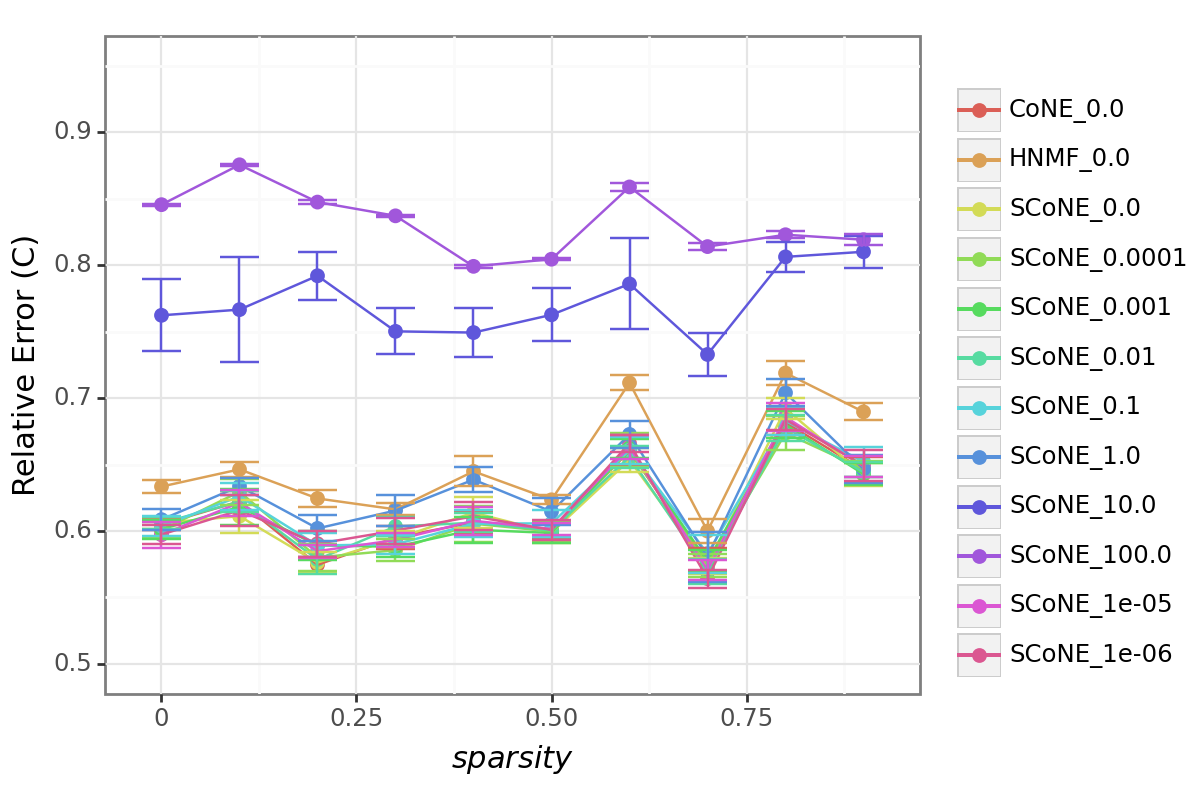

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 6 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_rel_C.jpeg


In [33]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_rel_error_C.csv',index_col=0)
summary = summary[summary['run_name'].isin(['SCoNE','HNMF','CoNE'])]
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
p = (
    ggplot(summary[summary['rank']==6], aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + labs(y="Relative Error (C)",x=r"$sparsity$",color="",title=f"")
    + theme_bw() 
)
p = p + theme(legend_title=element_text(size=9),figure_size=(6,4)) + ylim(0.5,.95)
print(p)
p.save('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_rel_C.jpeg')

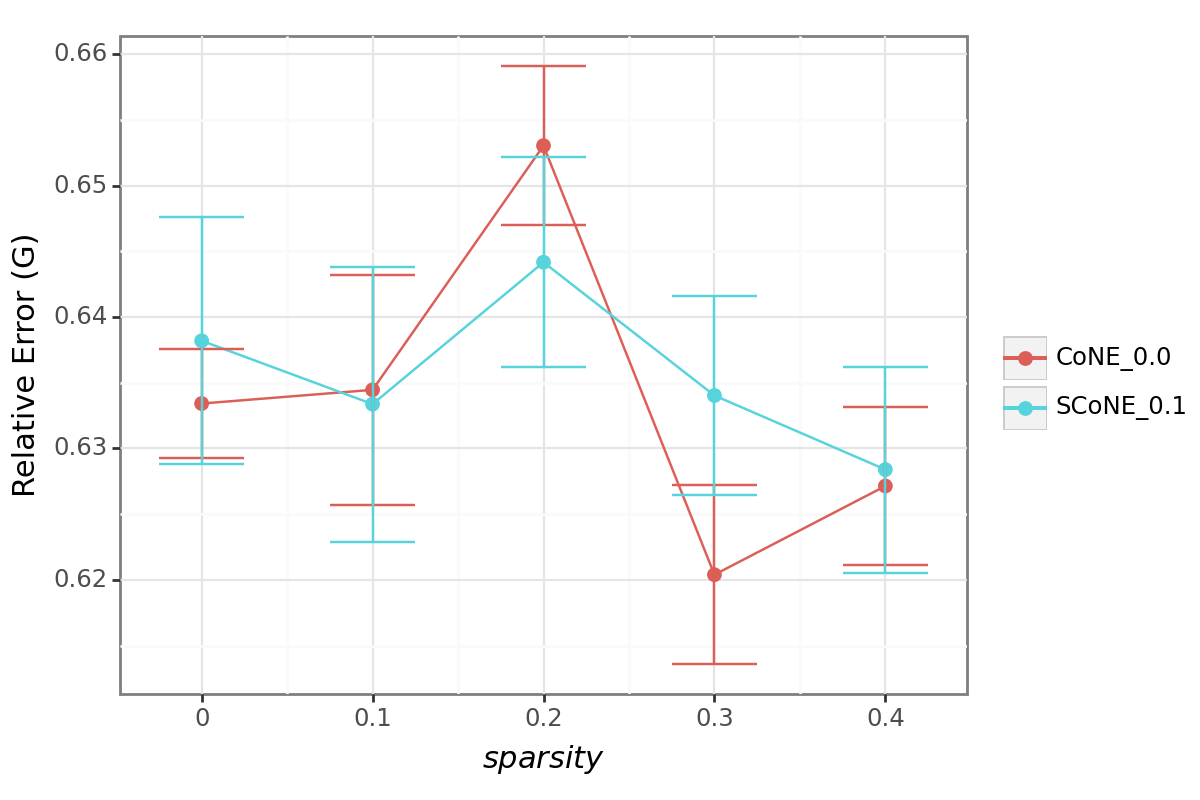

In [33]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_rel_error_G.csv',index_col=0)
summary = summary[(summary['run_name'].isin(['SCoNE','CoNE']))&(summary['lambda_H_G'].isin([0,1e-1]))&(summary['sparsity']<0.5)]
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
summary = summary[summary['run_name']!='SCoNE_0.0']
p = (
    ggplot(summary[summary['rank']==6], aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + labs(y="Relative Error (G)",x=r"$sparsity$",color="",title=f"")
    + theme_bw() 
)
p = p + theme(legend_title=element_text(size=9),figure_size=(6,4)) 
print(p)
#p.save('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_rel_G.jpeg')

In [58]:
import pandas as pd
from plotnine import *
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_sim.csv',index_col=0)
summary = summary[(summary['run_name'].isin(['SCoNE','CoNE']))&(summary['lambda_H_G'].isin([0,1e-2,1,10]))&(summary['sparsity']<0.6)].copy()
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
summary = summary[summary['run_name']!='SCoNE_0.0'].copy()
for rank in range(2,7):
    p = (
        ggplot(summary[(summary['rank']==6)&(summary['factor_matrix'].str.startswith('W'))], aes("sparsity", "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + labs(y="Similarity",x=r"$sparsity$",color="",title=f"")
        + theme_bw() 
    )
    p = p + theme(legend_title=element_text(size=9),figure_size=(10,4)) + facet_wrap('factor_matrix', nrow=1)
    p.save(f'/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_sim_rank_{rank}.jpeg',dpi=300)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 10 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_sim_rank_2.jpeg
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 10 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_sim_rank_3.jpeg
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 10 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: Plotn

In [51]:
summary[(summary['sparsity']==0.3)&(summary['rank']==6)&(summary['factor_matrix']=='W_G')]

,run_name,lambda_H_G,factor_matrix,sparsity,rank,n,mean,std,ci95,ymin,ymax
669,CoNE_0.0,0.00,W_G,0.3,6,10,0.811741,0.013972,0.008660,0.803081,0.820401
4065,SCoNE_0.01,0.01,W_G,0.3,6,10,0.814522,0.006845,0.004242,0.810280,0.818765
4665,SCoNE_1.0,1.00,W_G,0.3,6,10,0.815334,0.016069,0.009960,0.805374,0.825293
4965,SCoNE_10.0,10.00,W_G,0.3,6,10,0.691021,0.032724,0.020282,0.670738,0.711303


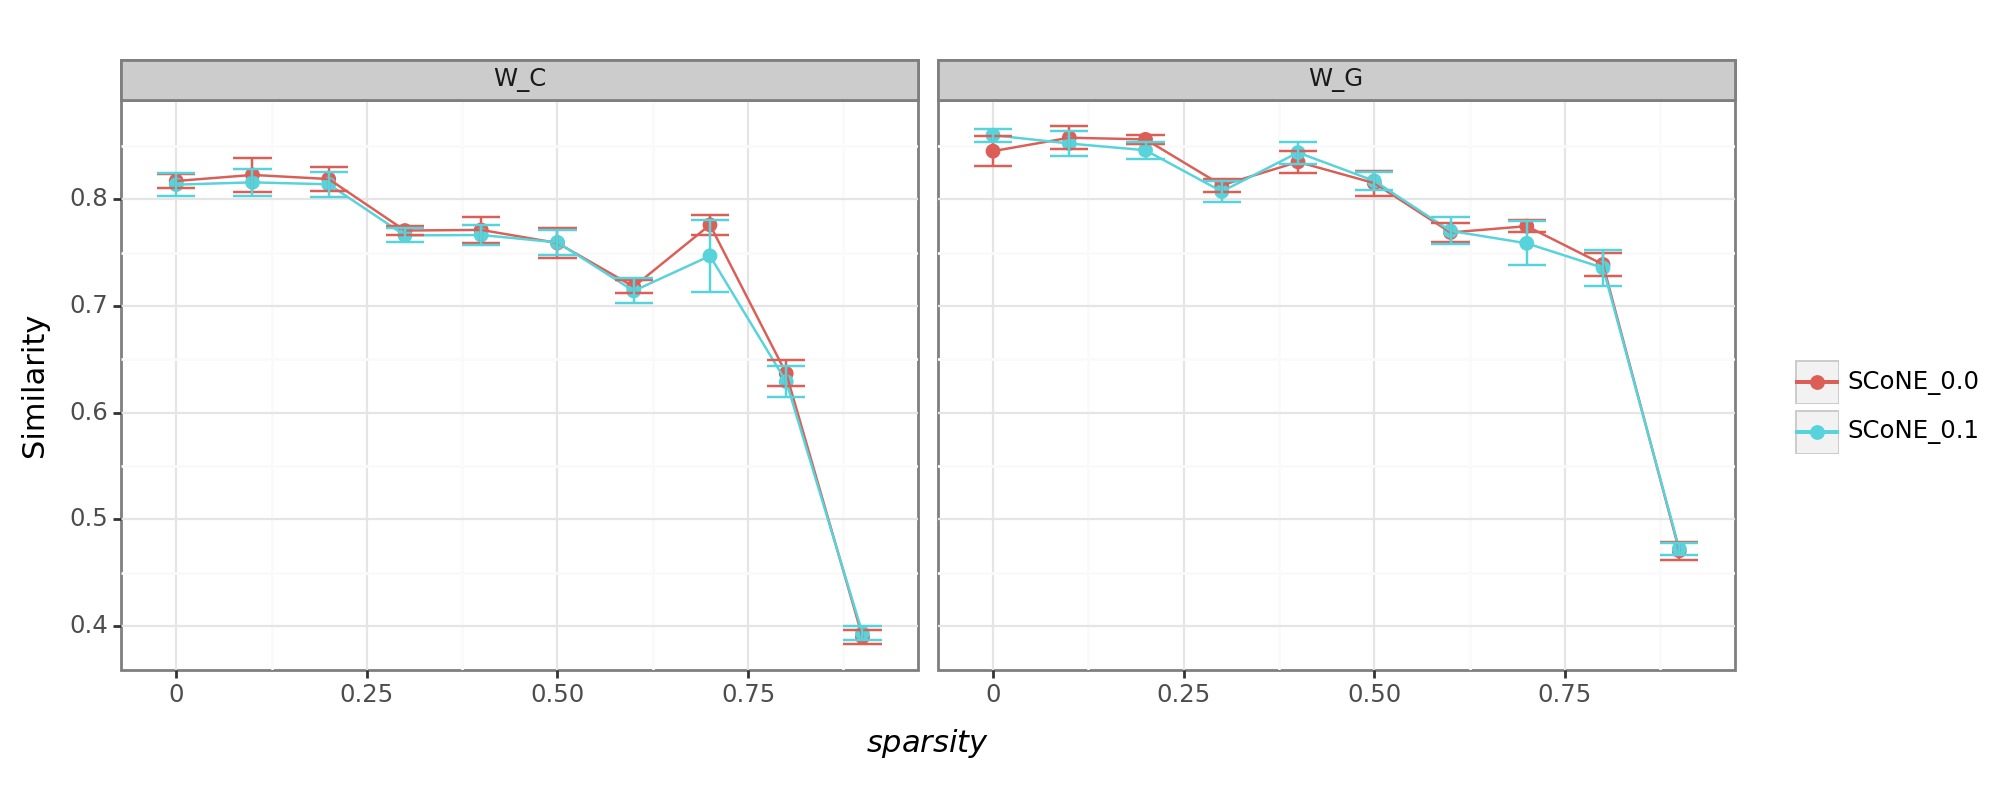

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 10 x 4 in image.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_sim.jpeg


In [ ]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_sim.csv',index_col=0)
summary = summary[summary['run_name'].isin(['SCoNE','HNMF','CoNE'])]
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
p = (
    ggplot(summary[(summary['rank']==6)&(summary['factor_matrix'].str.startswith('W'))], aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + labs(y="Similarity",x=r"$sparsity$",color="",title=f"")
    + theme_bw() 
)
p = p + theme(legend_title=element_text(size=9),figure_size=(10,4)) + facet_wrap('factor_matrix', nrow=1)
print(p)
p.save('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/figures/sparsity_sim.jpeg')

In [20]:
# testing basics that test code works
import numpy as np
W = np.random.rand(100,3)
H_true = np.random.rand(70,3)
X = np.random.poisson(W@H_true.T)
from algorithms.SCoNE import SCoNE_parallel, alternating_opt
factor_matrices, loss_function = SCoNE_parallel(G=None,C=X,Z=None, 
    rank=3, num_init=1,
    alpha=0,lambda_H_G=0, lambda_H_C=0, lambda_Gloss=0,                  # regularization parameters
    G_loss_type=None, C_loss_type='kl_div', # in 'kl_div',  'fro' or None (None indicates not fitting to data, i.e. if G_loss_type=None & C_loss_type='fro then C only optimization)
    max_inner=50, # options for pgd_armijo
    rho=0.1, # options for pgd_armijo (n shrink factor)
    sigma=1e-4, # options for pgd_armijo (Armijo constant)
    inner_ftol=1e-5, # options for pgd_armijo (stopping criteria for ftol)
    max_outer=200,
    min_outer=5,
    tol=1e-6,post_hoc_rescale=False,
    # if test is True, W is the only factor matrix that will be optimized (for train/test split)
    test=True,
    H_G=None, H_C=H_true, U_G=None, U_C=None)

In [21]:
np.linalg.norm(X - factor_matrices["W"]@H_true.T)

71.21479506742466

In [23]:
from sklearn.decomposition import non_negative_factorization
W_test_fromsklearn,H_same,n_iter = non_negative_factorization(X, H=H_true.T, update_H=False,
                                                   n_components=3,
                                                    init="random",
                                                    solver="mu",          # "mu" works well for fixed-H encoding
                                                    beta_loss="kullback-leibler",
                                                    max_iter=1000,
                                                    tol=1e-6,
                                                    random_state=0,)

In [24]:
np.linalg.norm(X - W_test_fromsklearn@H_true.T)

71.22721060267462

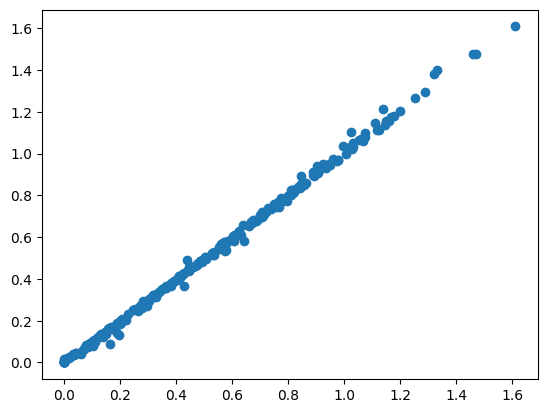

In [26]:
import matplotlib.pyplot as plt
plt.scatter(factor_matrices["W"].flatten(),W_test_fromsklearn.flatten())